<a href="https://colab.research.google.com/github/iestleija/5094-Matematicas/blob/Unidad2/Unidad2/Practices/5094_U2_AB6_266229.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos

- Curso: **Matemáticas y estadística para inteligencia artificial**

- Semestre: Enero-Junio

- Profesor: Dra. Helen Clara Peñate Rodríguez
- Actividad: **B6. Integrales**
- Alumno: Ismael Estrada Leija
- Matrícula: 266229

# Actividad B6. Integrales
enlace a colab: https://colab.research.google.com/drive/1GZiTwj_rzNBtmjUv1_js84cliJaZluFU?usp=sharing

In [244]:
import numpy as np
import matplotlib.pyplot as plt

# Instrucciones
1. Métrica del Sentimiento Acumulado
En esta tarea utilizaremos la integración definida y la integración numérica para comparar resultados exactos y aproximados del valor de una integral.
Hemos trabajado con datos que simulan la disposición de ciertos usuarios para
comprar un producto determinado. A este comportamiento se le conoce como
*análisis de sentimiento*. Con estos datos se puede calcular el impacto total de sentimiento de un grupo de usuarios. Esto nos daría la acumulación total de la probabilidad de compra en cierto rango de salarios. Con esto podemos identificar qué grupo de ingresos es el mejor objetivo de marketing y ajustar estrategias de precio según la capacidad de compra.
Si tenemos los datos de los salarios $s_i$ y la probabilidad de compra $p(s)$ en
un intervalo $s ∈ [a, b]$ de salarios, podemos calcular el impacto de sentimiento
como $$\int_{a}^{b} p(s)ds$$

2. Para los datos que utilizó en la tarea previa ¿Compramos el producto? calcule el impacto de sentimiento $I$ en el intervalo de salarios dados
utilizando:
  
    a) El método de sumas de Riemann.

    b) El método de los trapecios.

    c) Integrando directamente la función
$$p(s) = \frac {1}
{1+e^{−(s−s_0)}}$$
donde $s_0$ es el punto que escogió para obtener el desarrollo de Taylor.

d) Integrando directamente la aproximación de Taylor obtenida en la tarea anterior para la función $p(s)$.

3. Compare los resultados obtenidos en la pregunta anterior.


##Definición de Parámetros de Cálculo

### Intervalo de Integración
Para facilitar los cálculos manuales se establece el siguiente intervalo de integración, cercano a los datos proporcionados: $$s ϵ [10,14.66]$$

In [245]:
a=10;
b=14.66;
n=20;
delta_x = (b - a) / n

###Centro de Aproximación para Series de Taylor
El centro de aproximación que se uso en la práctica anterior y se usara nuevamente es: $$s_0=12$$

In [246]:
s_0 = 12

###Función original
La función original que se ha proporcionado es: $$p(s) = \frac {1}
{1+e^{−(s−s_0)}}$$

In [247]:
# original function in python code
def p(s):
  return 1/(1+np.exp(-(s-s_0)))

##Método de Riemann

In [248]:
#Calculates all  the rectangles data for the Riemann and Trapezoid sums
def get_integration_rectangles_data(a, n, dx, f):
  rectangle_data = {
      'left_x': [],
      'mid_x': [],
      'right_x': [],
      'left_y': [],
      'mid_y': [],
      'right_y':[],
      'trapezoid_height':[],
      'width':[]
  }
  for i in range(1, n + 1):
    left_x = a + (i - 1) * dx;
    right_x = a + i * dx;
    mid_x = 0.5 * (left_x + right_x);
    rectangle_data['left_x'].append(left_x)
    rectangle_data['mid_x'].append(mid_x)
    rectangle_data['right_x'].append(right_x)
    rectangle_data['left_y'].append(f(left_x))
    rectangle_data['mid_y'].append(f(mid_x))
    rectangle_data['right_y'].append(f(right_x))
    rectangle_data['trapezoid_height'].append((f(left_x) + f(right_x))/2) # Trapezoid height calculation
    rectangle_data['width'].append(dx)
  return rectangle_data

# Plots a Riemann sum
# Given the parameters
# rd = a list of data provided by the function get_rectangle_data
#
def plot_riemann_sum(rd, sum_type, ax):
  ax.plot(rd['mid_x'], rd['mid_y'], 'r', label='$f(x)=x^2$'); # Curva
  match sum_type:
    case 'left':
      riemann_sum = np.dot(rd['width'],rd['left_y'])
      ax.bar(rd['left_x'], rd['left_y'], rd['width'], alpha=0.3, align='edge', edgecolor='b', label='Suma Punto Medio') # Barras
      ax.scatter(rd['left_x'], rd['left_y'], color='blue', s=20);# Puntos de evaluación
      ax.set_title(f'Riemann (Izquierda) con n={n} es: {riemann_sum:.6f}');
    case 'mid':
      riemann_sum = np.dot(rd['width'],rd['mid_y'])
      ax.bar(rd['left_x'], rd['mid_y'], rd['width'], alpha=0.3, align='edge', edgecolor='b', label='Suma Punto Medio') # Barras
      ax.scatter(rd['mid_x'], rd['mid_y'], color='blue', s=20);# Puntos de evaluación
      ax.set_title(f'Riemann (Medio) con n={n} es: {riemann_sum:.6f}');
    case 'right':
      riemann_sum = np.dot(rd['width'],rd['right_y'])
      ax.bar(rd['left_x'], rd['right_y'], rd['width'], alpha=0.3, align='edge', edgecolor='b', label='Suma Punto Medio') # Barras
      ax.scatter(rd['right_x'], rd['right_y'], color='blue', s=20);# Puntos de evaluación
      ax.set_title(f'Riemann (Derecha) con n={n} es: {riemann_sum:.6f}');

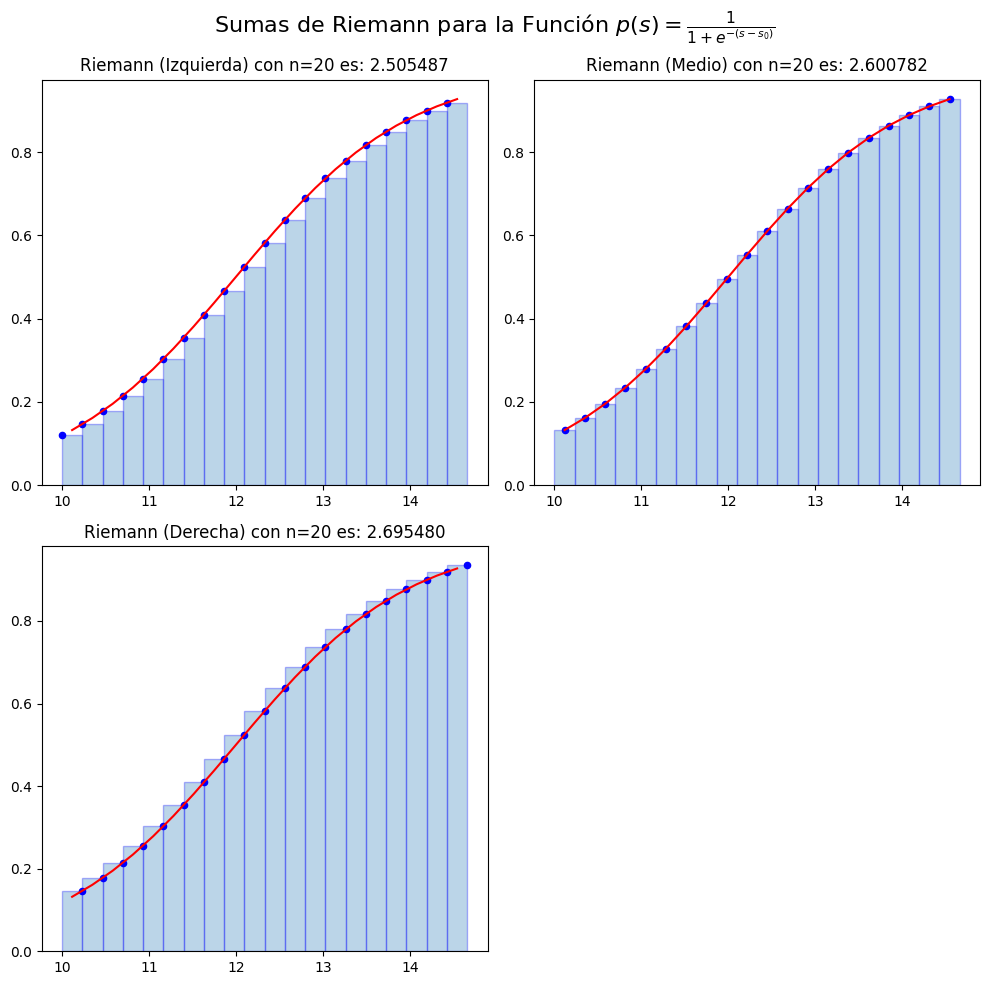

In [249]:
# Create a 2x2 array of plots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle(r'Sumas de Riemann para la Función $p(s) = \frac {1}{1+e^{-(s-s_0)}}$', fontsize=16)

rd = get_integration_rectangles_data(a, n, delta_x, p)
plot_riemann_sum(rd, 'left', axs[0,0])
plot_riemann_sum(rd, 'mid', axs[0,1])
plot_riemann_sum(rd, 'right', axs[1,0])
fig.delaxes(axs[1, 1])
plt.tight_layout()

## Método de los trapecios
Considerando que la fórmula para la ...

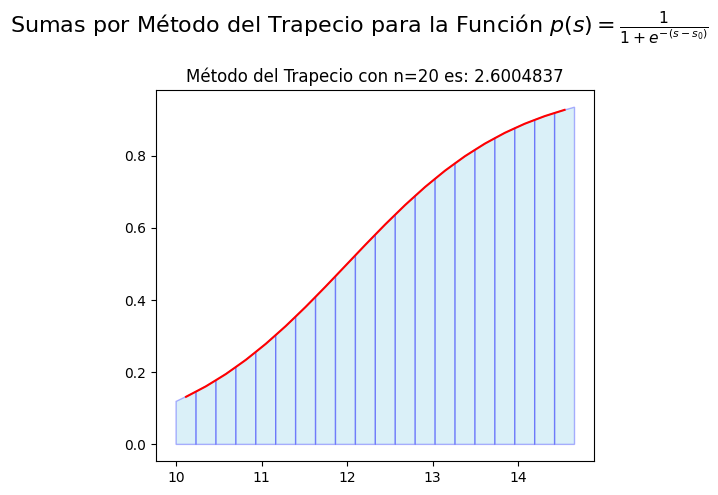

In [255]:
fig, ax = plt.subplots(1, 1, figsize=(5,5))
fig.suptitle(r'Sumas por Método del Trapecio para la Función $p(s) = \frac {1}{1+e^{-(s-s_0)}}$', fontsize=16)
widths = [delta_x] * n
trapezoid_sum = np.dot(widths,rd['trapezoid_height'])
ax.plot(rd['mid_x'], rd['mid_y'], 'r', label='$f(x)=x^2$'); # Curva
for i in range(n):
    # Definir las esquinas de cada trapecio
    xs = [rd['left_x'][i], rd['left_x'][i], rd['right_x'][i], rd['right_x'][i]]
    ys = [0, rd['left_y'][i], rd['right_y'][i], 0]
    ax.fill(xs, ys, 'skyblue', edgecolor='blue', alpha=0.3)
ax.set_title(f'Método del Trapecio con n={n} es: {trapezoid_sum:.7f}');
plt.tight_layout();

## Integración Directa de la Función

Para integrar la función proporcionada como una integral definida se expresará como sigue: $$\int_{10}^{14.66} p(s) = \frac {1}
{1+e^{−(s−s_0)}}$$

Refactorizamos la función como sigue:
$$p(s) = \frac {1}
{1+e^{−(s−s_0)}} * \frac {e^{(s−s_0)}}{e^{(s−s_0)}} =  \frac {e^{(s−s_0)}}{e^{(s−s_0)} + 1} $$

A partir de aquí, para resolverlo utilizaremos el método de la sustitución o cambio de variable, determinando $$v =  {e^{(s−s_0)}+1}$$
Considerando que el diferencial de $e^u = e^udu $ $$dv=e^{(s−s_0)}ds$$
Con esto podemos expresar la integral ahora como sigue:
$$\int_{10}^{14.66} \frac {e^{(s−s_0)}}{e^{(s−s_0)} + 1}ds = \int_{10}^{14.66} \frac {dv}{v}$$
También se sabe que $\int \frac{1}{v}dv = ln |v|+C$
De allí que,
$$\int_{10}^{14.66} \frac {1}
{1+e^{−(s−s_0)}} = ln|{e^{(s−s_0)} + 1}||_{10}^{14.66}$$

###Resultado de la Integración Directa de la Función

In [270]:
import math

# Define the function f(s) = ln|e^(s-s0) + 1|
def f(s, s_0):
    return math.log(abs(math.exp(s-s_0) + 1))

result = f(14.66,12) - f(10,12);
print(f"La integración directa de la función original resultó en: {result}");


La integración directa de la función original resultó en: 2.60068224536712


##Integración de la Aproximación de Taylor

En la práctica anterior se encontro la aproximación a la función con series de Taylor de tercer grado como sigue: $$T_3(x) = 0.5 + 0.25(x-x_0)-1/48(x-x_0)^3$$
con $x_0 = 12$,
de dónde podemos reescribir la aproximación como:  $$T_3(x) = 0.5 + 0.25(x-12)-1/48(x-12)^3$$  $$T_3(x) = 0.5 + 0.25x-3-1/48(x-12)^3$$
Considerando $$(a+b)^3 = a^3 + 3a^2b + 3ab^2 + b^3$$
Expandiremos $$(x-12)^3 = x^3 - 36x^2 + 432x - 1728$$
Entonces $$ \frac{1}{48} (x-12)^3 = \frac{1}{48}x^3-\frac{3}{4}x^2+9x-36$$
Remplazando en la serie de Taylor,
$$T_3(x) = 0.5 + 0.25x-3-(\frac{1}{48}x^3-\frac{3}{4}x^2+9x-36)$$
La función simplificada es,
$$T_3(x) = -\frac{1}{48}x^3+\frac{3}{4}x^2-8.75x+33.5$$
y la integral definida en el intervalo $[10,14]$ de esta última función es
$$\int_{10}^{14} T_3(x)  = -\frac{1}{192}x^4+\frac{1}{4}x^3-4.375x^2+33.5x\Big|_{10}^{14}$$
Los resultados parciales son:
$$r_{14} = -\frac{1}{192} (14.66)^4+\frac {1}{4} (14.66)^3 - \frac{35}{8} (14.66)^2 + 33.5 (14.66)$$
$$r_{14}=-240.566225+787.665674-940.25575+491.11 = 97.9536994$$
$$r_{10}=-\frac{10000}{192}+\frac{1000}{4}-\frac{3500}{8}+335$$ $$r_{10}=\frac{-1250+6000-10500+8040}{24}=\frac{2290}{24} = 95.4166667$$

asi que,

$$\int_{10}^{14} T_3(x)  = r_{14} - r_{10} = 97.9536994 - 95.4166667 $$$$\int_{10}^{14} T_3(x)  = 2.53703273$$

#Comparativa de Resultados
La siguiente tabla sumariza los distintos resultados obtenidos de los diferentes métodos utilizados para la integración de la función proporcionada.
Es notorio que los métodos de aproximación mas cercanos al valor de la integral son el método de los trapecios y el método de sumas de Riemann con su variante que usa el punto medio.
En el caso del método de los polinomios de Taylor es importante anotar que usamos el grado 3 y puede mejorarse la precisión elevando el grado de cálculo.

| Método            | Resultado     |
| ----------------- | ------------- |
| Riemann Izquierdo |     2.5054870 |
| Taylor            |     2.5370327 |
| Trapecios         |     2.6004837 |
| **Integral Directa**  |     **2.6006822** |
| Riemann Medio     |     2.6007820 |
| Riemann Derecho   |     2.6954800 |

# Conclusión
Se realizaron cálculos y visualizaciones de diferentes métodos de aproximación a la integral de una función comparando la precisión con respecto a la integración directa.

Durante la presente actividad se trabajo con los conceptos matemáticos expuestos por la docente, se tomo referencia del libro "Essential Math
for Data Science" y se usaron las librerías numpy (NumPy team, 2026) y pyplot(Hunter et al., 2026) de python dentro del entorno de google colab.

#Referencias
Hunter, J., Dale, D., Firing, E., & Droettboom, M. (2026). Pyplot tutorial—Matplotlib 3.10.8 documentation. Pyplot tutorial. https://matplotlib.org/stable/tutorials/pyplot.html

NumPy team. (2026). NumPy. https://numpy.org/
